In [ ]:
# # 초기 1회 실행
# from google.colab import drive
# drive.mount('/content/drive')

Mounted at /content/drive


# Lesson 5-4 Machine_Learning2_appendix


In [ ]:
## 필요 패키지 설치 및 import
import importlib.util
import subprocess
import sys
def install_and_import(packages):
    for pkg in packages:
        package = pkg
        try:
            importlib.util.find_spec(package)
            print(f"{package} is already installed.")
        except ImportError:
            # 모듈이 설치되어 있지 않은 경우 설치시도
            print(f"{package} is not installed. Installing...")
            subprocess.check_call([sys.executable, "-m", "pip", "install", package])
            subprocess.check_call(["conda", "install", package, "-y"])

            # 설치 후 다시 임포트를 시도
            importlib.import_module(package)
            print(f"{package} has been successfully installed.")

        # finally:
        #     globals()[package] = importlib.import_module(package)
        except Exception as e:
            # 설치 중 예외가 발생한 경우, 에러 메시지를 출력
            print(f"An error occurred while installing {package}: {str(e)}")

# 예시 사용법
install_and_import(['factor-analyzer'])


factor-analyzer is already installed.


In [ ]:
ppath = '/content/drive/MyDrive/5. STUDY_ETC/Metacode/lesson5'

In [ ]:
## 필요 모듈 임포트
import os, sys, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats



# 차원 축소

## PCA 에서 상위 주성분들만 사용했을때 머신러닝 모델 결과 비교

In [ ]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt

# 데이터 로드
data = load_breast_cancer()
X, y = data.data, data.target

# 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 데이터 스케일링
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# PCA 적용
pca = PCA()
X_train_pca = pca.fit_transform(X_train_scaled)

# 누적 분산 비율 계산
cumulative_variance_ratio = np.cumsum(pca.explained_variance_ratio_)

# 90% 누적 분산을 설명하는 주성분 개수 찾기
n_components_90 = np.argmax(cumulative_variance_ratio >= 0.9) + 1

print(f"90% 누적 분산을 설명하는 주성분 개수: {n_components_90}")

# PCA를 90% 누적 분산 주성분으로 다시 적용
pca_90 = PCA(n_components=n_components_90)
X_train_pca_90 = pca_90.fit_transform(X_train_scaled)
X_test_pca_90 = pca_90.transform(X_test_scaled)

# 원본 데이터로 의사결정나무 모델 훈련
dt_original = DecisionTreeClassifier(random_state=42)
dt_original.fit(X_train_scaled, y_train)
y_pred_original = dt_original.predict(X_test_scaled)

# PCA 적용 데이터로 의사결정나무 모델 훈련
dt_pca = DecisionTreeClassifier(random_state=42)
dt_pca.fit(X_train_pca_90, y_train)
y_pred_pca = dt_pca.predict(X_test_pca_90)

# 성능 비교
print("원본 데이터 모델 성능:")
print(classification_report(y_test, y_pred_original))

print("\nPCA 적용 데이터 모델 성능:")
print(classification_report(y_test, y_pred_pca))

# 누적 분산 비율 시각화
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(cumulative_variance_ratio) + 1), cumulative_variance_ratio, 'bo-')
plt.axhline(y=0.9, color='r', linestyle='--')
plt.axvline(x=n_components_90, color='g', linestyle='--')
plt.title('Cumulative Explained Variance Ratio')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance Ratio')
plt.grid(True)
plt.show()

# 특성 중요도 비교
feature_importance_original = pd.Series(dt_original.feature_importances_, index=data.feature_names)
feature_importance_pca = pd.Series(dt_pca.feature_importances_, index=[f'PC{i+1}' for i in range(n_components_90)])

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
feature_importance_original.sort_values().plot(kind='barh')
plt.title('Feature Importance (Original)')
plt.subplot(1, 2, 2)
feature_importance_pca.sort_values().plot(kind='barh')
plt.title('Feature Importance (PCA)')
plt.tight_layout()
plt.show()

## FA

#### 데이터 읽기

In [ ]:
## 데이터 읽기
df = pd.read_csv(ppath +'/1. data/Admission_Predict2.csv')
df

,GRE.Score,TOEFL.Score,University.Rating,SOP,LOR,CGPA,Research,Chance.of.Admit
0,337,118,4,4.5,4.5,9.65,1,high
1,324,107,4,4.0,4.5,8.87,1,medium
2,316,104,3,3.0,3.5,8.00,1,medium
3,322,110,3,3.5,2.5,8.67,1,high
4,314,103,2,2.0,3.0,8.21,0,medium
...,...,...,...,...,...,...,...,...
395,324,110,3,3.5,3.5,9.04,1,high
396,325,107,3,3.0,3.5,9.11,1,high
397,330,116,4,5.0,4.5,9.45,1,high
398,312,103,3,3.5,4.0,8.78,0,medium


### 데이터 표준화

In [ ]:
## 데이터 전처리
# 결측값 확인 및 제거
# 종속 변수 'Chance of Admit' 제거
dependent_var = 'Chance.of.Admit'
df_independent = df.drop(columns=[dependent_var], axis = 1)

# 결측값 확인 및 제거
df_independent = df_independent.dropna()


from sklearn.preprocessing import StandardScaler
## 데이터 표준화
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_independent)

### Correlation plot

In [ ]:
## 변수 간 상관 행렬 계산
corr_matrix = pd.DataFrame(df_scaled,
                                                           columns = df_independent.columns).corr()
corr_matrix


,GRE.Score,TOEFL.Score,University.Rating,SOP,LOR,CGPA,Research
GRE.Score,1.000000,0.835977,0.668976,0.612831,0.557555,0.833060,0.580391
TOEFL.Score,0.835977,1.000000,0.695590,0.657981,0.567721,0.828417,0.489858
University.Rating,0.668976,0.695590,1.000000,0.734523,0.660123,0.746479,0.447783
SOP,0.612831,0.657981,0.734523,1.000000,0.729593,0.718144,0.444029
LOR,0.557555,0.567721,0.660123,0.729593,1.000000,0.670211,0.396859
CGPA,0.833060,0.828417,0.746479,0.718144,0.670211,1.000000,0.521654
Research,0.580391,0.489858,0.447783,0.444029,0.396859,0.521654,1.000000


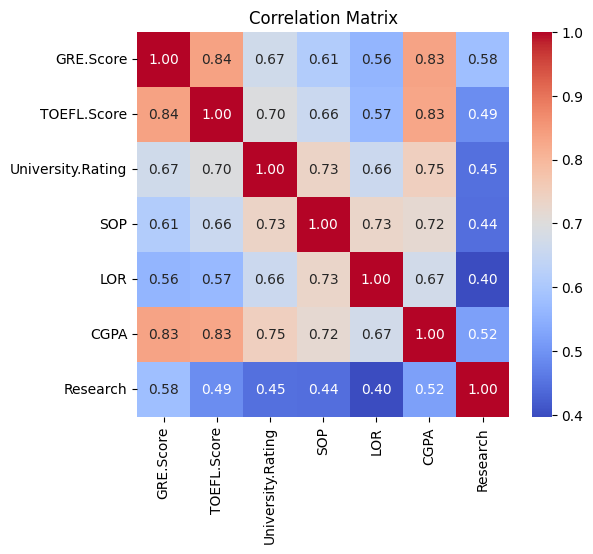

In [ ]:
## 상관 행렬 시각화
plt.figure(figsize=(6, 5))
sns.heatmap(corr_matrix,
                            annot = True,
                            cmap = 'coolwarm',
                            fmt = ".2f")
plt.title('Correlation Matrix')
plt.show()

### KMO 검정

- KMO (Kaiser-Meyer-Olkin) Test Score는 요인 분석을 수행하기전, 데이터가 얼마나 적합한지 평가하는 지표
- 0에서 1 사이의 값을 가지며, 값이 높을수록 요인 분석에 적합한 데이터임을 의미함

- KMO Test Score 해석  
      0.90 ~ 1.00: 매우 적합 (Marvelous)
      0.80 ~ 0.89: 적합 (Meritorious)
      0.70 ~ 0.79: 보통 적합 (Middling)
      0.60 ~ 0.69: 보통 이하 적합 (Mediocre)
      0.50 ~ 0.59: 부적합 (Miserable)
      < 0.50: 요인 분석에 적합하지 않음 (Unacceptable)









In [ ]:
from factor_analyzer import FactorAnalyzer, calculate_kmo

## KMO 검정 수행
kmo_all, kmo_model = calculate_kmo(df_scaled)
kmo_model


#  이 데이터는 요인 분석을 수행하기에 매우 적합..
# 변수 간의 상관성이 요인 분석에 충분히 높은 수준임을 나타내며, 요인 분석을 통해 유의미한 결과를 도출할 가능성이 높음..

0.9029506982455264

### 요인 개수 결정

In [ ]:
## 요인의 개수 결정
# 고유값 (Eigenvalues) 확인
fa = FactorAnalyzer(rotation=None)
fa.fit(df_scaled)
eigenvalues, _ = fa.get_eigenvalues()
eigenvalues


array([4.87301767, 0.72487834, 0.5466917 , 0.30990434, 0.24521051,
       0.15862259, 0.14167484])

In [ ]:
## 각 요인의 고유값 출력
eigenvalues, _ = fa.get_eigenvalues()
print("Eigenvalues for each factor:\n", eigenvalues) ## 요인별 고유값

Eigenvalues for each factor:
 [4.87301767 0.72487834 0.5466917  0.30990434 0.24521051 0.15862259
 0.14167484]


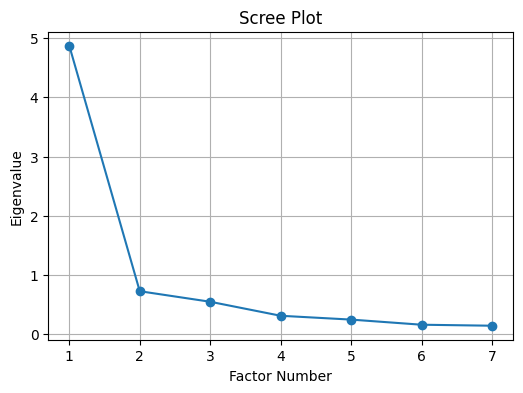

In [ ]:
## Scree plot (스크리 플롯)
plt.figure(figsize=(6, 4))
plt.plot(range(1, len(eigenvalues) + 1), eigenvalues,
                marker = 'o')
plt.title('Scree Plot')
plt.xlabel('Factor Number')
plt.ylabel('Eigenvalue')
plt.grid()
plt.show()

### 요인 회전 방법 결정 및 요인 분석 수행

In [ ]:
from factor_analyzer import FactorAnalyzer

## 요인 회전 방법 결정 및 요인 분석 수행
# 일반적으로 varimax 회전 방법 사용
fa = FactorAnalyzer(n_factors = 3,
                                         rotation = 'varimax')  # 요인 개수는 고유값과 스크리 플롯을 기준으로 설정
fa.fit(df_scaled)

##요인 부하량 (Factor Loadings)
factor_loadings = fa.loadings_
factor_loadings


array([[0.32571774, 0.87475278, 0.34187832],
       [0.39649008, 0.54056553, 0.6818536 ],
       [0.66387541, 0.39011229, 0.32961596],
       [0.79710906, 0.30504527, 0.25210029],
       [0.74735468, 0.29089617, 0.17151164],
       [0.56122303, 0.57598119, 0.43177205],
       [0.31506642, 0.48659042, 0.15040834]])

In [ ]:
## 요인 점수 계산
factor_scores = fa.transform(df_scaled)  # 요인 점수를 계산하여 각 관측치에 대해 3개의 요인 점수 생성

## 요인 점수를 데이터프레임으로 변환
factor_scores_df = pd.DataFrame(factor_scores, columns=['Factor_1', 'Factor_2', 'Factor_3'])
factor_scores_df

,Factor 1,Factor 2,Factor 3
0,0.565108,1.400081,1.000754
1,0.829704,0.710706,-0.825071
2,-0.301803,0.326054,-0.833712
3,-0.553918,0.563528,0.403151
4,-1.157335,0.328225,-0.527488
...,...,...,...
395,-0.087286,0.680427,0.181612
396,-0.276177,1.095621,-0.469073
397,1.103417,0.587374,0.826539
398,0.620859,-0.404997,-0.762305


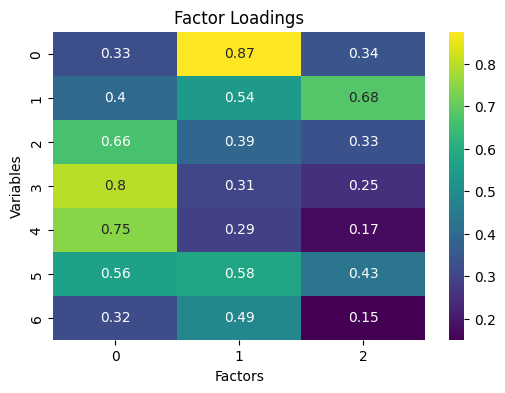

In [ ]:
## 요인 분석 결과 확인
# 요인 부하량 시각화
plt.figure(figsize = (6, 4))
sns.heatmap(factor_loadings,
                            annot = True,
                            cmap = 'viridis')
plt.title('Factor Loadings')
plt.xlabel('Factors')
plt.ylabel('Variables')
plt.show()



- 요인 부하량(Factor Loadings)
   - 각 셀의 값: 변수와 요인 간의 관계의 강도  
      - 양수: 해당 변수와 요인이 양의 관계를 가짐  
      - 음수: 해당 변수와 요인이 음의 관계를 가짐  
      - 값이 클수록 (보통 |0.4| 이상): 해당 변수와 요인이 강한 연관 의미
- 요인 간 변수의 기여  
  - Factor 0  
      변수 2 (0.66), 변수 3 (0.8), 변수 4 (0.75)가 주요하게 기여하고 있음  
      이 요인은 주로 변수 2, 3, 4와 관련된 요인일 가능성이 있음  
  - Factor 1  
      변수 0 (0.87), 변수 5 (0.58), 변수 1 (0.54)이 기여하고 있음  
      이 요인은 변수 0, 1, 5와 관련된 요인일 가능성이 있음  
  - Factor 2   
      변수 1 (0.68), 변수 5 (0.43)이 기여하고 있음  
      이 요인은 주로 변수 1과 5와 관련된 요인으로 볼 수 있음  


### 요인 점수 시각화 (Y값이 있는 경우)

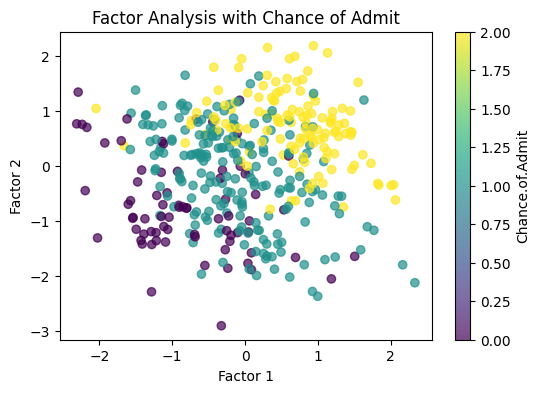

In [ ]:
## Chance of Admit 변수를 이용한 요인 점수 시각화
factor_scores = fa.transform(df_scaled)  # 요인 점수 계산

## Chance of Admit 변수를 수치형으로 매핑
color_mapping = {"low": 0, "medium": 1, "high": 2}  # "low" = 0, "medium" = 1, "high" = 2
color_values = df["Chance.of.Admit"].map(color_mapping)  # 종속 변수를 수치형으로 변환


plt.figure(figsize = (6, 4))
plt.scatter(factor_scores[:, 0],
                      factor_scores[:, 1],
                       c = color_values,
                      cmap = "viridis",
                      alpha = 0.7)
plt.colorbar(label = "Chance.of.Admit")
plt.xlabel("Factor 1")
plt.ylabel("Factor 2")
plt.title("Factor Analysis with Chance of Admit")
plt.show()

In [ ]:
# EOS